In [1]:
import torch
from torchvision import transforms
import torchvision
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((32,32))
])

In [4]:
train_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/leaf_disease/data', transform=transform)

In [5]:
train_data

Dataset ImageFolder
    Number of datapoints: 3388
    Root location: /content/drive/MyDrive/leaf_disease/data
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
           )

In [6]:
train_data.class_to_idx

{'Apple___black_rot': 0,
 'Apple___healthy': 1,
 'Bell_pepper___bacterial_spot': 2,
 'Bell_pepper___healthy': 3,
 'Rice___bacterial_blight': 4,
 'Rice___blast': 5,
 'Rice___brown_spot': 6,
 'Tomato___septoria_leaf_spot': 7,
 'Tomato___spider_mites': 8}

In [7]:
test_data = torchvision.datasets.ImageFolder('/content/drive/MyDrive/leaf_disease/data', transform=transform)

In [8]:
test_data

Dataset ImageFolder
    Number of datapoints: 3388
    Root location: /content/drive/MyDrive/leaf_disease/data
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
           )

In [9]:
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=True)

In [11]:
sample = (next(iter(train_loader))[0][0]).permute((1,2,0))

In [12]:
sample.shape

torch.Size([32, 32, 3])

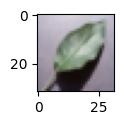

In [13]:
plt.figure(figsize=(1,1))
plt.imshow(sample)

In [14]:
import os

train_path = '/content/drive/MyDrive/leaf_disease/data'

In [15]:
train_data.class_to_idx

{'Apple___black_rot': 0,
 'Apple___healthy': 1,
 'Bell_pepper___bacterial_spot': 2,
 'Bell_pepper___healthy': 3,
 'Rice___bacterial_blight': 4,
 'Rice___blast': 5,
 'Rice___brown_spot': 6,
 'Tomato___septoria_leaf_spot': 7,
 'Tomato___spider_mites': 8}

In [16]:
healthy =[]
diseases = []

for d in os.listdir(train_path):
  temp = d.split('___')
  if 'healthy' in temp:
    healthy.append(d)
  else:
    diseases.append(d)


In [17]:
len(healthy)

2

In [18]:
len(diseases)

7

In [19]:
count = dict()

for d in os.listdir(train_path):
  count[d] = len(os.listdir(train_path+'/'+d))

In [20]:
count

{'Tomato___septoria_leaf_spot': 22,
 'Rice___bacterial_blight': 1584,
 'Apple___black_rot': 26,
 'Bell_pepper___bacterial_spot': 33,
 'Apple___healthy': 1617,
 'Bell_pepper___healthy': 25,
 'Tomato___spider_mites': 22,
 'Rice___brown_spot': 37,
 'Rice___blast': 22}

In [21]:
count_df = pd.DataFrame(count.values(), index=count.keys(), columns=['no of images'])

In [22]:
count_df

,no of images
Tomato___septoria_leaf_spot,22
Rice___bacterial_blight,1584
Apple___black_rot,26
Bell_pepper___bacterial_spot,33
Apple___healthy,1617
Bell_pepper___healthy,25
Tomato___spider_mites,22
Rice___brown_spot,37
Rice___blast,22


In [23]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [24]:
device

'cuda'

In [25]:
c =0
for x in train_loader:
  c+=1
  x[0].to(device)
  x[1].to(device)

In [26]:
c

106

In [27]:
70295/32

2196.71875

In [28]:
from torch import nn
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels = 3, out_channels=128, kernel_size=3, padding=1),
        nn.LeakyReLU(inplace=True),
        nn.BatchNorm2d(128),
        nn.MaxPool2d(kernel_size=2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels = 128, out_channels=256, kernel_size=3, padding=1),
        nn.LeakyReLU(inplace=True),
        nn.BatchNorm2d(256),
        nn.MaxPool2d(kernel_size=2)
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels = 256, out_channels=512, kernel_size=3, padding=1),
        nn.LeakyReLU(inplace=True),
        nn.BatchNorm2d(512),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classify = nn.Sequential(
        nn.Dropout(0.2),
        nn.Flatten(),
        nn.Linear(in_features=512*4*4, out_features=512),
        nn.LeakyReLU(inplace=True),
        nn.Linear(in_features=512, out_features=38)
    )

  def forward(self, x):
    x1 = self.block1(x)
    x2 = self.block2(x1)
    x3 = self.block3(x2)
    x4 = self.classify(x3)
    return x4





In [31]:
model = CNN().to(device)

In [30]:
loss = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters(), lr=3e-4)
epochs = 5

In [33]:
3e-4

0.0003

In [35]:
from sklearn.metrics import accuracy_score, confusion_matrix
model.to(device)

for epoch in range(epochs):
  for b, (feature, target) in enumerate(train_loader):
    feature = feature.to(device)
    target = target.to(device)

    model.train()

    pred = model(feature)

    loss_fn = loss(pred.squeeze(), target)

    optim.zero_grad()

    loss_fn.backward()

    optim.step()

  model.eval()
  all_preds = []
  all_targets = []

  with torch.inference_mode():
    for feature_val, target_val in test_loader:
      feature_val = feature_val.to(device)
      target_val = target_val.to(device)

      pred_val = model(feature_val)
      loss_val = loss(pred_val.squeeze(), target_val)

      all_preds.extend(torch.argmax(torch.softmax(pred_val, dim=1), dim=1).cpu().numpy())
      all_targets.extend(target_val.cpu().numpy())

  accuracy = accuracy_score(all_targets, all_preds)
  print(f"Epoch {epoch} | Loss on Training : {loss_fn.item()} | Accuracy on testing {accuracy}")





Epoch 0 | Loss on Training : 3.743299722671509 | Accuracy on testing 0.003246753246753247
Epoch 1 | Loss on Training : 3.762326955795288 | Accuracy on testing 0.003246753246753247
Epoch 2 | Loss on Training : 3.7860782146453857 | Accuracy on testing 0.002656434474616293
Epoch 3 | Loss on Training : 3.7386951446533203 | Accuracy on testing 0.005608028335301062
Epoch 4 | Loss on Training : 3.7921175956726074 | Accuracy on testing 0.002656434474616293


In [36]:
testing = next(iter(test_loader))

In [37]:
f = testing[0][0]
t = testing[1][0]

In [38]:
t

tensor(1)

In [39]:
test_data.class_to_idx

{'Apple___black_rot': 0,
 'Apple___healthy': 1,
 'Bell_pepper___bacterial_spot': 2,
 'Bell_pepper___healthy': 3,
 'Rice___bacterial_blight': 4,
 'Rice___blast': 5,
 'Rice___brown_spot': 6,
 'Tomato___septoria_leaf_spot': 7,
 'Tomato___spider_mites': 8}

In [40]:
output = model(f.unsqueeze(dim=0).to(device))

In [41]:
output.shape

torch.Size([1, 38])

In [42]:
torch.argmax(torch.softmax(output, dim=1))

tensor(29, device='cuda:0')

In [43]:
512*4*4

8192

In [44]:
model.eval()
all_preds = []
all_targets = []

with torch.inference_mode():
  for feature_val, target_val in test_loader:
    feature_val = feature_val.to(device)
    target_val = target_val.to(device)

    pred_val = model(feature_val)
    loss_val = loss(pred_val.squeeze(), target_val)

    all_preds.extend(torch.argmax(torch.softmax(pred_val, dim=1), dim=1).cpu().numpy())
    all_targets.extend(target_val.cpu().numpy())

accuracy = accuracy_score(all_targets, all_preds)
confusion_m = confusion_matrix(all_targets, all_preds)

In [45]:
accuracy*100

0.26564344746162927

<Axes: >

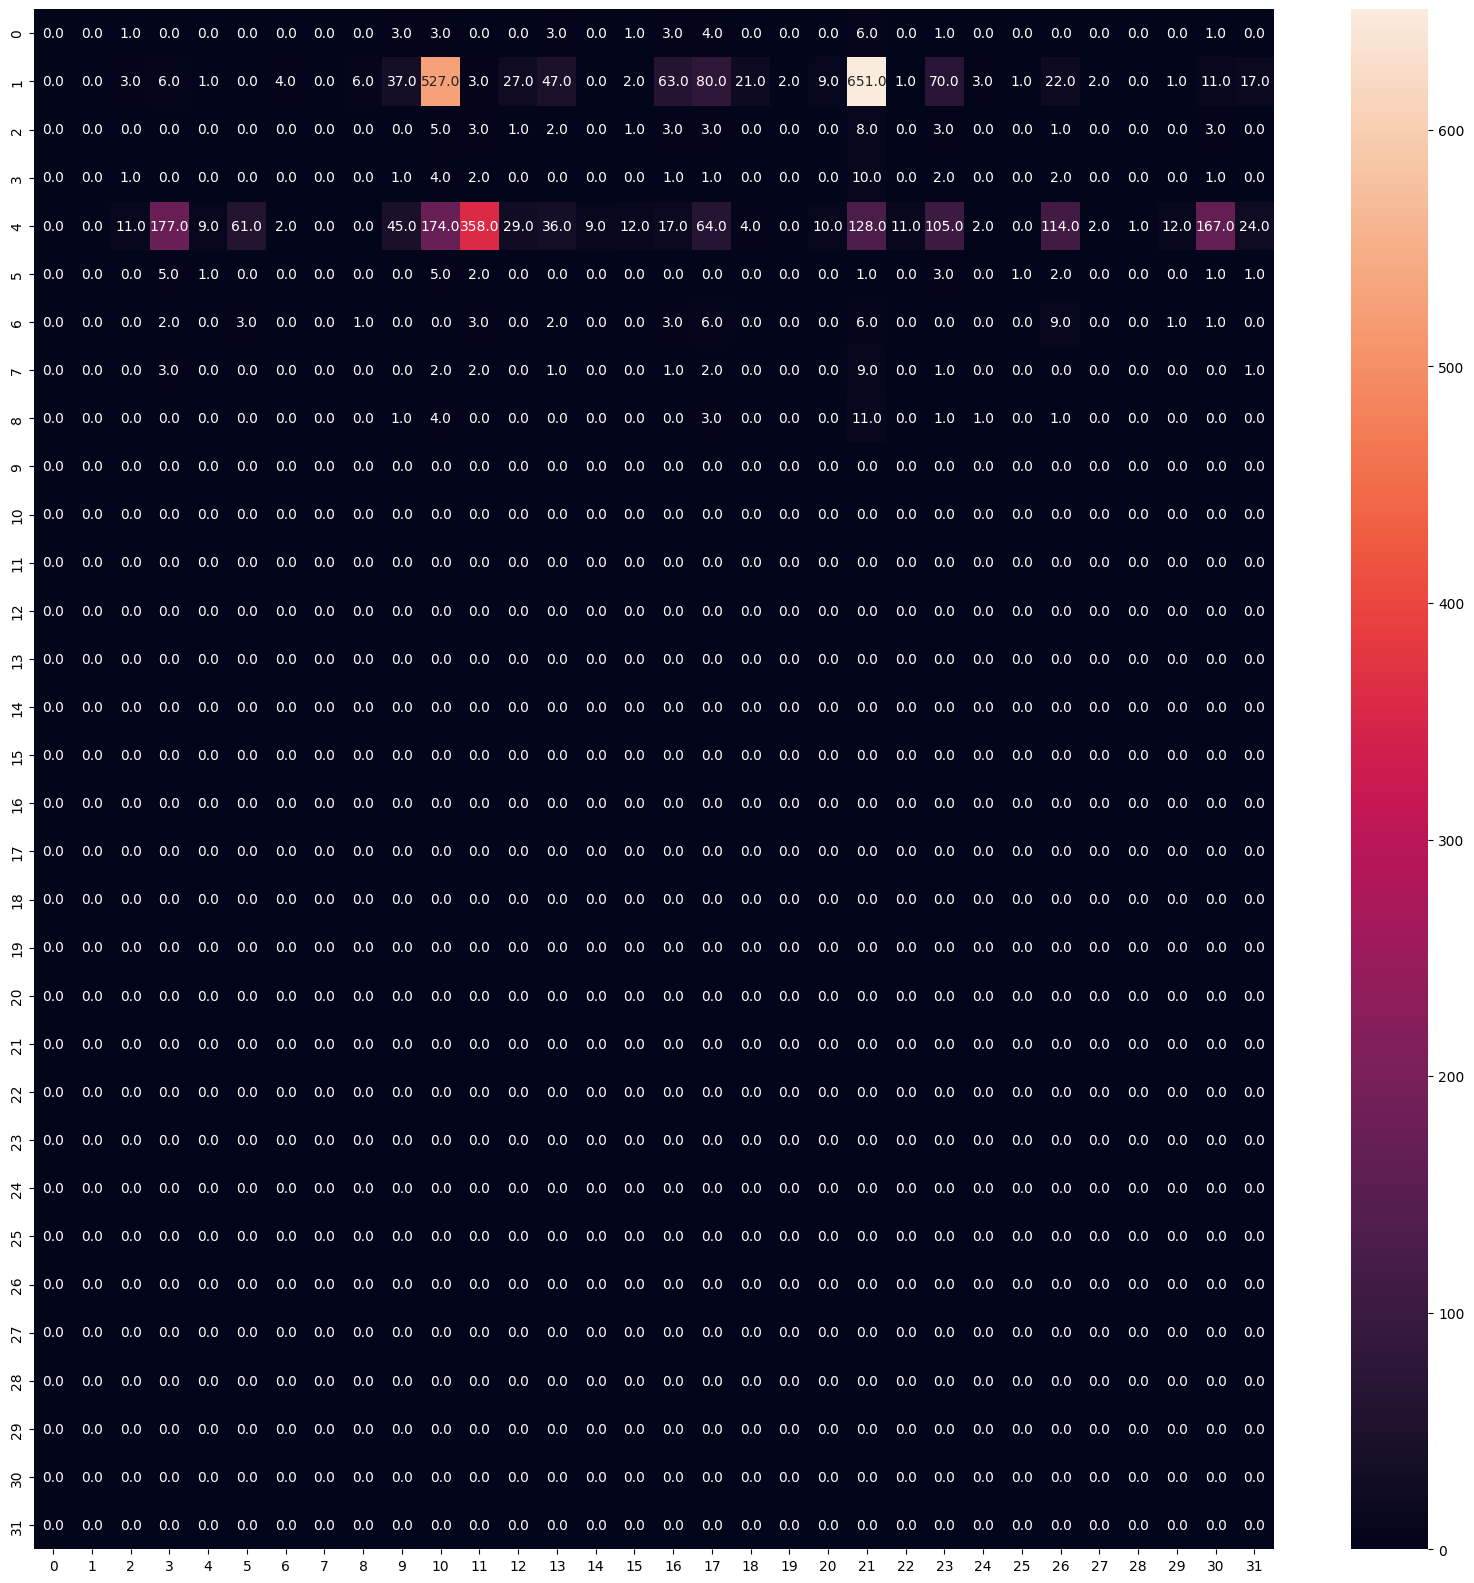

In [46]:
plt.figure(figsize=(20,20))
sns.heatmap(confusion_m, annot=True, fmt='.1f')

In [47]:
torch.save(model,'cnn_model.h5')